# Creation of a groundwater model for Spülfeld

First we create a groundwater model grid for the study area Spülfeld. The grid has a size of 88x64 cells.

In [1]:
import flopy
import numpy as np
import scipy
import matplotlib.pyplot as plt
from flopy.discretization import StructuredGrid
from flopy.utils import Raster

delc = np.ones((88,)) * 10 
delr = np.ones((64,)) * 10
xll = 32615349.675000000745
yll = 5973009.509999999776
angrot = 0
modelgrid = StructuredGrid(delc=delc, delr=delr, xoff=xll, yoff=yll)

rstr = Raster.load("flopy/spuelfeld_coarse_mask.tif")
resampled = rstr.resample_to_grid(
    modelgrid,
    band=rstr.bands[0],
    method="nearest",
)

print(delc)

[10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.
 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.
 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.
 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.
 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.]


Before: xll:32615349.675; yll:5973009.51; rotation:0.0; units:undefined; lenuni:0

After: xll:32615349.675; yll:5973009.51; rotation:0; units:undefined; lenuni:0


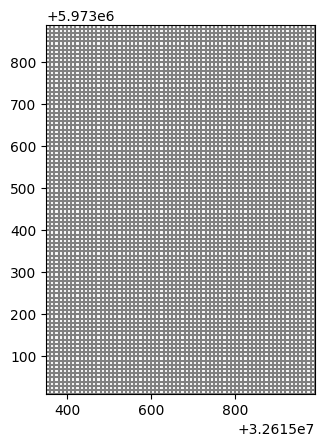

In [2]:
# show the coordinate info before setting it
print(f"Before: {modelgrid}\n")

# set reference infromation
modelgrid.set_coord_info(xoff=xll, yoff=yll, angrot=angrot)

print(f"After: {modelgrid}")
modelgrid.plot()